In [8]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

In [45]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import librosa
import librosa.display
from IPython.display import Audio, display
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from src.models.rawnet2 import RawNet
from src.data_utils import ASVDataset, collate_fn_asvspoof

In [10]:
def extract_input_gradients(model, waveform, device, target_class=None):
    model.eval()
    
    if waveform.dim() == 1:
        waveform = waveform.unsqueeze(0)
    
    wav = waveform.to(device).detach().requires_grad_(True)
    
    with torch.backends.cudnn.flags(enabled=False):
        logits = model(wav)
    
    log_probs = F.log_softmax(logits, dim=1)
    
    if target_class is not None:
        target = log_probs[0, target_class]
    else:
        target = log_probs.sum()
    
    input_grad = torch.autograd.grad(
        outputs=target,
        inputs=wav,
        create_graph=False,
        retain_graph=False,
    )[0]
    
    grad_np = input_grad.detach().cpu().squeeze().numpy()
    logits_np = logits.detach().cpu().squeeze().numpy()
    pred_class = int(logits.argmax(dim=1).item())
    
    return grad_np, logits_np, pred_class

In [11]:
def visualize_single(model, waveform, label, mask=None, device='cuda',
                     sr=16000, title=None, figsize=(14, 10)):
    grad, logits, pred = extract_input_gradients(model, waveform, device)
    wav_np = waveform.detach().cpu().numpy()
    
    if wav_np.ndim > 1:
        wav_np = wav_np.squeeze()
    
    grad_abs = np.abs(grad)
    
    # Smooth gradient for visualization
    smooth_window = int(sr * 0.025)  # 25ms
    if smooth_window % 2 == 0:
        smooth_window += 1
    grad_smooth = np.convolve(grad_abs, np.ones(smooth_window) / smooth_window, mode='same')
    
    # Normalize for coloring
    grad_norm = grad_smooth / (grad_smooth.max() + 1e-10)
    
    # Time axis
    t = np.arange(len(wav_np)) / sr
    
    # Compute spectrogram
    S = librosa.feature.melspectrogram(y=wav_np, sr=sr, n_mels=80, fmax=8000)
    S_db = librosa.power_to_db(S, ref=np.max)
    
    # Map gradient to spectrogram time frames
    spec_times = librosa.times_like(S_db, sr=sr)
    grad_spec = np.interp(spec_times, t, grad_norm)
    
    # Create figure
    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(3, 1, height_ratios=[1, 1, 0.7], hspace=0.35)
    
    label_str = "bonafide" if label == 1 else "spoof"
    pred_str = "bonafide" if pred == 1 else "spoof"
    correct = "✓" if pred == label else "✗"
    
    if title is None:
        title = f"True: {label_str} | Pred: {pred_str} {correct}"
    
    fig.suptitle(title, fontsize=14, fontweight='bold')
    
    # Waveform with gradient heatmap
    ax1 = fig.add_subplot(gs[0])
    
    # Plot waveform
    ax1.plot(t, wav_np, color='#2b2b2b', linewidth=0.3, alpha=0.7)
    
    # Overlay gradient as colored background
    cmap = plt.cm.YlOrRd
    for i in range(0, len(t) - 1, max(1, len(t) // 2000)):
        ax1.axvspan(t[i], t[min(i + len(t) // 2000, len(t) - 1)],
                    alpha=grad_norm[i] * 0.6,
                    color=cmap(grad_norm[i]),
                    linewidth=0)
    
    # Show mask regions if provided
    if mask is not None:
        mask_np = mask.detach().cpu().numpy()
        if mask_np.ndim > 1:
            mask_np = mask_np.squeeze()
        silence_regions = mask_np > 0.5
        for i in range(0, len(t) - 1, max(1, len(t) // 500)):
            end_i = min(i + len(t) // 500, len(t) - 1)
            if silence_regions[i]:
                ax1.axvspan(t[i], t[end_i], alpha=0.15, color='blue', linewidth=0)
    
    ax1.set_ylabel('Amplitude')
    ax1.set_title('Waveform + Gradient Magnitude (red=high attention, blue=masked silence)')
    ax1.set_xlim(0, t[-1])
    
    # Spectrogram with gradient overlay
    ax2 = fig.add_subplot(gs[1])
    
    img = librosa.display.specshow(S_db, x_axis='time', y_axis='mel',
                                    sr=sr, fmax=8000, ax=ax2, cmap='magma')
    
    # Overlay gradient as transparency on top of spectrogram
    extent = [0, t[-1], 0, 8000]
    grad_2d = np.tile(grad_spec, (20, 1))  # stretch vertically
    ax2.imshow(grad_2d, aspect='auto', extent=extent, origin='lower',
               cmap='spring', alpha=0.4,
               norm=Normalize(vmin=0, vmax=1))
    
    ax2.set_title('Mel Spectrogram + Gradient Overlay')
    ax2.set_ylabel('Frequency (Hz)')
    
    # Gradient magnitude plot
    ax3 = fig.add_subplot(gs[2])
    
    ax3.fill_between(t, 0, grad_smooth, alpha=0.4, color='#e74c3c')
    ax3.plot(t, grad_smooth, color='#c0392b', linewidth=0.8)
    
    if mask is not None:
        mask_np = mask.detach().cpu().numpy().squeeze()
        mask_scaled = mask_np * grad_smooth.max() * 0.3
        ax3.fill_between(t, 0, mask_scaled, alpha=0.2, color='blue', label='Masked (silence)')
        ax3.legend(loc='upper right', fontsize=9)
    
    ax3.set_xlabel('Time (s)')
    ax3.set_ylabel('|∇x|')
    ax3.set_title('Smoothed Gradient Magnitude')
    ax3.set_xlim(0, t[-1])
    
    plt.tight_layout()
    return fig

In [12]:
def visualize_comparison(model_baseline, model_rrr, waveform, label, 
                         mask=None, device='cuda', sr=16000, figsize=(14, 10)):
    grad_base, logits_base, pred_base = extract_input_gradients(model_baseline, waveform, device)
    grad_rrr, logits_rrr, pred_rrr = extract_input_gradients(model_rrr, waveform, device)
    
    wav_np = waveform.detach().cpu().numpy().squeeze()
    t = np.arange(len(wav_np)) / sr
    
    # Smooth
    win = int(sr * 0.025)
    if win % 2 == 0:
        win += 1
    kernel = np.ones(win) / win
    grad_base_smooth = np.convolve(np.abs(grad_base), kernel, mode='same')
    grad_rrr_smooth = np.convolve(np.abs(grad_rrr), kernel, mode='same')
    
    # Normalize both to same scale
    max_val = max(grad_base_smooth.max(), grad_rrr_smooth.max()) + 1e-10
    grad_base_norm = grad_base_smooth / max_val
    grad_rrr_norm = grad_rrr_smooth / max_val
    
    label_str = "bonafide" if label == 1 else "spoof"
    
    fig, axes = plt.subplots(4, 1, figsize=figsize, 
                              gridspec_kw={'height_ratios': [0.6, 1, 1, 1]})
    
    fig.suptitle(f'Gradient Comparison — True label: {label_str}', 
                 fontsize=14, fontweight='bold')
    
    # Waveform
    axes[0].plot(t, wav_np, color='#2b2b2b', linewidth=0.4)
    if mask is not None:
        mask_np = mask.detach().cpu().numpy().squeeze()
        for i in range(0, len(t) - 1, max(1, len(t) // 500)):
            end_i = min(i + len(t) // 500, len(t) - 1)
            if mask_np[i] > 0.5:
                axes[0].axvspan(t[i], t[end_i], alpha=0.2, color='blue', linewidth=0)
    axes[0].set_ylabel('Amplitude')
    axes[0].set_title('Waveform (blue = masked silence regions)')
    axes[0].set_xlim(0, t[-1])
    
    # Baseline gradients
    pred_str_base = "bonafide" if pred_base == 1 else "spoof"
    correct_base = "✓" if pred_base == label else "✗"
    
    axes[1].fill_between(t, 0, grad_base_smooth, alpha=0.5, color='#e74c3c')
    axes[1].plot(t, grad_base_smooth, color='#c0392b', linewidth=0.6)
    axes[1].set_ylabel('|∇x|')
    axes[1].set_title(f'Baseline — Pred: {pred_str_base} {correct_base}')
    axes[1].set_xlim(0, t[-1])
    
    # Row 2: RRR gradients
    pred_str_rrr = "bonafide" if pred_rrr == 1 else "spoof"
    correct_rrr = "✓" if pred_rrr == label else "✗"
    
    axes[2].fill_between(t, 0, grad_rrr_smooth, alpha=0.5, color='#3498db')
    axes[2].plot(t, grad_rrr_smooth, color='#2980b9', linewidth=0.6)
    axes[2].set_ylabel('|∇x|')
    axes[2].set_title(f'RRR (λ₁=1e8) — Pred: {pred_str_rrr} {correct_rrr}')
    axes[2].set_xlim(0, t[-1])
    
    # Difference
    diff = grad_rrr_norm - grad_base_norm
    axes[3].fill_between(t, 0, diff, where=(diff > 0), alpha=0.5, 
                          color='#3498db', label='RRR attends more')
    axes[3].fill_between(t, 0, diff, where=(diff < 0), alpha=0.5, 
                          color='#e74c3c', label='Baseline attends more')
    axes[3].axhline(y=0, color='black', linewidth=0.5)
    axes[3].set_xlabel('Time (s)')
    axes[3].set_ylabel('Δ|∇x|')
    axes[3].set_title('Attention Shift (blue = RRR gained, red = RRR lost)')
    axes[3].legend(loc='upper right', fontsize=9)
    axes[3].set_xlim(0, t[-1])
    
    plt.tight_layout()
    return fig

In [13]:
def visualize_batch(model, dataloader, device, n_samples=8, sr=16000,
                    figsize=(16, 2.5), save_path=None):
    model.eval()
    
    samples = []
    for batch in dataloader:
        if len(batch) == 4:
            features, labels, sys_ids, masks = batch
        else:
            features, labels, sys_ids = batch
            masks = [None] * len(labels)
        
        for i in range(features.shape[0]):
            if len(samples) >= n_samples:
                break
            samples.append((features[i], int(labels[i]), 
                           masks[i] if not isinstance(masks, list) else None))
        if len(samples) >= n_samples:
            break
    
    fig, axes = plt.subplots(n_samples, 1, figsize=(figsize[0], figsize[1] * n_samples))
    if n_samples == 1:
        axes = [axes]
    
    fig.suptitle('Input Gradient Magnitudes Across Samples', fontsize=14, fontweight='bold')
    
    for idx, (wav, label, mask) in enumerate(samples):
        grad, logits, pred = extract_input_gradients(model, wav, device)
        wav_np = wav.cpu().numpy().squeeze()
        t = np.arange(len(wav_np)) / sr
        
        grad_abs = np.abs(grad)
        win = int(sr * 0.025)
        if win % 2 == 0:
            win += 1
        grad_smooth = np.convolve(grad_abs, np.ones(win) / win, mode='same')
        grad_norm = grad_smooth / (grad_smooth.max() + 1e-10)
        
        ax = axes[idx]
        
        # Waveform
        ax.plot(t, wav_np, color='#2b2b2b', linewidth=0.3, alpha=0.6)
        
        # Gradient overlay
        cmap = plt.cm.YlOrRd
        for i in range(0, len(t) - 1, max(1, len(t) // 1000)):
            end_i = min(i + len(t) // 1000, len(t) - 1)
            ax.axvspan(t[i], t[end_i], alpha=grad_norm[i] * 0.6,
                       color=cmap(grad_norm[i]), linewidth=0)
        
        label_str = "bonafide" if label == 1 else "spoof"
        pred_str = "bonafide" if pred == 1 else "spoof"
        correct = "✓" if pred == label else "✗"
        ax.set_ylabel(f'{label_str}\n→{pred_str}{correct}', fontsize=8, rotation=0, 
                       labelpad=50, va='center')
        ax.set_xlim(0, t[-1])
        ax.set_yticks([])
        
        if idx < n_samples - 1:
            ax.set_xticks([])
    
    axes[-1].set_xlabel('Time (s)')
    plt.tight_layout()
    
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved to {save_path}")
    
    return fig

In [14]:
def visualize_gradient_stats(model, dataloader, device, sr=16000, 
                              max_batches=50, figsize=(12, 8)):
    model.eval()
    
    speech_grad_energy = {'bonafide': [], 'spoof': []}
    silence_grad_energy = {'bonafide': [], 'spoof': []}
    
    n_batches = 0
    for batch in dataloader:
        if n_batches >= max_batches:
            break
        
        if len(batch) == 4:
            features, labels, _, masks = batch
        else:
            print("Dataloader must return (features, labels, sys_ids, masks)")
            return None
        
        for i in range(features.shape[0]):
            grad, _, _ = extract_input_gradients(model, features[i], device)
            grad_sq = grad ** 2
            
            mask_np = masks[i].cpu().numpy().squeeze()
            speech_mask = mask_np < 0.5    # 0 = speech
            silence_mask = mask_np > 0.5   # 1 = silence
            
            label_str = 'bonafide' if int(labels[i]) == 1 else 'spoof'
            
            if speech_mask.sum() > 0:
                speech_energy = grad_sq[speech_mask].mean()
                speech_grad_energy[label_str].append(speech_energy)
            
            if silence_mask.sum() > 0:
                silence_energy = grad_sq[silence_mask].mean()
                silence_grad_energy[label_str].append(silence_energy)
        
        n_batches += 1
        if n_batches % 10 == 0:
            print(f"Processed {n_batches}/{max_batches} batches...")
    
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    fig.suptitle('Gradient Energy Distribution: Speech vs Silence Regions', 
                 fontsize=14, fontweight='bold')
    
    # bonafide speech vs silence
    ax = axes[0, 0]
    if speech_grad_energy['bonafide'] and silence_grad_energy['bonafide']:
        ax.hist(np.log10(np.array(speech_grad_energy['bonafide']) + 1e-20), 
                bins=30, alpha=0.6, color='#3498db', label='Speech', density=True)
        ax.hist(np.log10(np.array(silence_grad_energy['bonafide']) + 1e-20), 
                bins=30, alpha=0.6, color='#e74c3c', label='Silence', density=True)
    ax.set_title('Bonafide')
    ax.set_xlabel('log₁₀(mean gradient²)')
    ax.legend()
    
    # spoof speech vs silence
    ax = axes[0, 1]
    if speech_grad_energy['spoof'] and silence_grad_energy['spoof']:
        ax.hist(np.log10(np.array(speech_grad_energy['spoof']) + 1e-20), 
                bins=30, alpha=0.6, color='#3498db', label='Speech', density=True)
        ax.hist(np.log10(np.array(silence_grad_energy['spoof']) + 1e-20), 
                bins=30, alpha=0.6, color='#e74c3c', label='Silence', density=True)
    ax.set_title('Spoof')
    ax.set_xlabel('log₁₀(mean gradient²)')
    ax.legend()
    
    # ratio of silence/speech energy
    ax = axes[1, 0]
    for label_str, color in [('bonafide', '#2ecc71'), ('spoof', '#9b59b6')]:
        if speech_grad_energy[label_str] and silence_grad_energy[label_str]:
            min_len = min(len(speech_grad_energy[label_str]), 
                         len(silence_grad_energy[label_str]))
            ratios = np.array(silence_grad_energy[label_str][:min_len]) / \
                     (np.array(speech_grad_energy[label_str][:min_len]) + 1e-20)
            ax.hist(np.log10(ratios + 1e-10), bins=30, alpha=0.5, 
                    color=color, label=label_str, density=True)
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1, label='Equal energy')
    ax.set_xlabel('log₁₀(silence_energy / speech_energy)')
    ax.set_title('Silence/Speech Gradient Ratio')
    ax.legend()
    
    # summary bar chart
    ax = axes[1, 1]
    categories = ['Bonafide\nSpeech', 'Bonafide\nSilence', 'Spoof\nSpeech', 'Spoof\nSilence']
    means = [
        np.mean(speech_grad_energy['bonafide']) if speech_grad_energy['bonafide'] else 0,
        np.mean(silence_grad_energy['bonafide']) if silence_grad_energy['bonafide'] else 0,
        np.mean(speech_grad_energy['spoof']) if speech_grad_energy['spoof'] else 0,
        np.mean(silence_grad_energy['spoof']) if silence_grad_energy['spoof'] else 0,
    ]
    colors = ['#3498db', '#e74c3c', '#3498db', '#e74c3c']
    bars = ax.bar(categories, means, color=colors, alpha=0.7)
    ax.set_ylabel('Mean gradient²')
    ax.set_title('Average Gradient Energy')
    ax.ticklabel_format(axis='y', style='scientific', scilimits=(0, 0))
    
    plt.tight_layout()
    return fig

In [18]:
DEVICE = 'cuda:1'
MODEL_SAVE_DIR = Path.cwd().parent / 'models'
BASELINE_WEIGHTS_FNAME = 'rawnet_final.pth'
RRR_WEIGHTS_FNAME = 'rawnet_rrr_subset_attempt.pth'
BASELINE_CHECKPOINT_PATH = MODEL_SAVE_DIR / BASELINE_WEIGHTS_FNAME
RRR_CHECKPOINT_PATH = MODEL_SAVE_DIR / RRR_WEIGHTS_FNAME

In [19]:
model_config = {
    'margin': 2,
    'nb_samp': 32000,
    'first_conv': 128,
    'in_channels': 1,
    'filts': [128, [128, 128], [128, 512], [512, 512]],
    'blocks': [2, 4],
    'nb_fc_node': 1024,
    'gru_node': 1024,
    'nb_gru_layer': 3,
    'nb_classes': 2
}

baseline_model = RawNet(model_config, DEVICE)
baseline_model.load_state_dict(torch.load(BASELINE_CHECKPOINT_PATH)['model_state_dict'])
baseline_model.to(DEVICE).eval()

/tmp/ipykernel_8304/2023593164.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  baseline_model.load_state_dict(torch.load(BASELINE_CHECKPOINT_PATH)['model_state_dict'])


RawNet(
  (Sinc_conv): SincConv()
  (first_bn): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (selu): SELU(inplace=True)
  (block0): Sequential(
    (0): Residual_block(
      (lrelu): LeakyReLU(negative_slope=0.3)
      (conv1): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (mp): MaxPool1d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (block1): Sequential(
    (0): Residual_block(
      (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (lrelu): LeakyReLU(negative_slope=0.3)
      (conv1): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv1d(128, 128, kernel_size=

In [20]:
model_config = {
    'margin': 2,
    'nb_samp': 32000,
    'first_conv': 128,
    'in_channels': 1,
    'filts': [128, [128, 128], [128, 512], [512, 512]],
    'blocks': [2, 4],
    'nb_fc_node': 1024,
    'gru_node': 1024,
    'nb_gru_layer': 3,
    'nb_classes': 2
}

rrr_model = RawNet(model_config, DEVICE)
rrr_model.load_state_dict(torch.load(RRR_CHECKPOINT_PATH)['model_state_dict'])
rrr_model.to(DEVICE).eval()

/tmp/ipykernel_8304/1989094246.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  rrr_model.load_state_dict(torch.load(RRR_CHECKPOINT_PATH)['model_state_dict'])


RawNet(
  (Sinc_conv): SincConv()
  (first_bn): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (selu): SELU(inplace=True)
  (block0): Sequential(
    (0): Residual_block(
      (lrelu): LeakyReLU(negative_slope=0.3)
      (conv1): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (mp): MaxPool1d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (block1): Sequential(
    (0): Residual_block(
      (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (lrelu): LeakyReLU(negative_slope=0.3)
      (conv1): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv1d(128, 128, kernel_size=

In [25]:
DATA_PATH = str(Path.cwd().parent / 'data' / 'ASVspoof2019_LA')
PROTOCOLS_PATH = str(Path.cwd().parent / 'data' / 'ASVspoof2019_LA' / 'ASVspoof2019_LA_cm_protocols')
CACHE_DIR = str(Path.cwd().parent / 'data_caches')

FEATURE_NAME = 'raw'
tf = lambda x: torch.tensor(x)

In [26]:
train_data = ASVDataset(
    database_path=DATA_PATH, protocols_path=PROTOCOLS_PATH, 
    is_train=True, feature_name=FEATURE_NAME, cache_dir=CACHE_DIR,
    max_duration=2.0, pad_to_max=True, transform=tf, use_vad_masks=True
)

sysid_dict_inv {0: '-', 1: 'A01', 2: 'A02', 3: 'A03', 4: 'A04', 5: 'A05', 6: 'A06'}
data_root /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_cm_protocols
dset_name train
protocols_fname train.trn
protocols_dir /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_cm_protocols
files_dir /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_train/flac
protocols_file /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt
cache_fname /root/reproduction-salvi-et-al/data_caches/cache_train_LA_raw_2.0s_pad.npy
mask_cache_fname /root/reproduction-salvi-et-al/data_caches/cache_train_LA_raw_2.0s_pad_masks.npy
Loading dataset from cache: /root/reproduction-salvi-et-al/data_caches/cache_train_LA_raw_2.0s_pad.npy
Dataset loaded from cache successfully
Loading VAD masks from cache: /root/reproduction-salvi-et-al/data_caches/cache_train_LA_raw_2.0s_pad_masks.npy
VAD masks loaded from cache succ

In [27]:
dev_data = ASVDataset(
    database_path=DATA_PATH, protocols_path=PROTOCOLS_PATH, 
    is_train=False, feature_name=FEATURE_NAME, cache_dir=CACHE_DIR,
    max_duration=2.0, pad_to_max=True, transform=tf, use_vad_masks=True
)

sysid_dict_inv {0: '-', 1: 'A01', 2: 'A02', 3: 'A03', 4: 'A04', 5: 'A05', 6: 'A06'}
data_root /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_cm_protocols
dset_name dev
protocols_fname dev.trl
protocols_dir /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_cm_protocols
files_dir /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_dev/flac
protocols_file /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.dev.trl.txt
cache_fname /root/reproduction-salvi-et-al/data_caches/cache_dev_LA_raw_2.0s_pad.npy
mask_cache_fname /root/reproduction-salvi-et-al/data_caches/cache_dev_LA_raw_2.0s_pad_masks.npy
Loading dataset from cache: /root/reproduction-salvi-et-al/data_caches/cache_dev_LA_raw_2.0s_pad.npy
Dataset loaded from cache successfully
VAD mask cache not found. Computing masks...


Computing VAD masks:   0%|          | 0/24844 [00:00<?, ?sample/s]

Saving VAD mask cache to: /root/reproduction-salvi-et-al/data_caches/cache_dev_LA_raw_2.0s_pad_masks.npy
VAD mask cache saved successfully


In [28]:
eval_data = ASVDataset(
    database_path=DATA_PATH, protocols_path=PROTOCOLS_PATH,
    is_eval=True, feature_name=FEATURE_NAME, cache_dir=CACHE_DIR,
    max_duration=2.0, pad_to_max=True, transform=tf, use_vad_masks=True
)

sysid_dict_inv {0: '-', 1: 'A07', 2: 'A08', 3: 'A09', 4: 'A10', 5: 'A11', 6: 'A12', 7: 'A13', 8: 'A14', 9: 'A15', 10: 'A16', 11: 'A17', 12: 'A18', 13: 'A19'}
data_root /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_cm_protocols
dset_name eval
protocols_fname eval.trl
protocols_dir /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_cm_protocols
files_dir /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_eval/flac
protocols_file /root/reproduction-salvi-et-al/data/ASVspoof2019_LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.eval.trl.txt
cache_fname /root/reproduction-salvi-et-al/data_caches/cache_eval_LA_raw_2.0s_pad.npy
mask_cache_fname /root/reproduction-salvi-et-al/data_caches/cache_eval_LA_raw_2.0s_pad_masks.npy
Loading dataset from cache: /root/reproduction-salvi-et-al/data_caches/cache_eval_LA_raw_2.0s_pad.npy
Dataset loaded from cache successfully
VAD mask cache not found. Computing masks...


Computing VAD masks:   0%|          | 0/71237 [00:00<?, ?sample/s]

Saving VAD mask cache to: /root/reproduction-salvi-et-al/data_caches/cache_eval_LA_raw_2.0s_pad_masks.npy
VAD mask cache saved successfully


In [29]:
demo_indices = [0, 3000, 3000 + 3800 * 2, 3000 + 3800 * 4]
train_demos = []
dev_demos = []
eval_demos = []

for idx, sample_idx in enumerate(demo_indices):
    D, label, meta, mask = train_data[sample_idx]
    train_demos.append((D.numpy(), label, meta, mask))

for idx, sample_idx in enumerate(demo_indices):
    D, label, meta, mask = dev_data[sample_idx]
    dev_demos.append((D.numpy(), label, meta, mask))

for idx, sample_idx in enumerate(demo_indices):
    D, label, meta, mask = eval_data[sample_idx]
    eval_demos.append((D.numpy(), label, meta, mask))

In [32]:
for audio, label, meta, _ in train_demos:
    print(f"\n{'Bonafide' if label == 1.0 else 'Spoof'} - {meta.file_name}")
    print(f"System: {train_data.sysid_dict_inv[meta.sys_id]}")
    display(Audio(audio, rate=16000))


Bonafide - LA_T_1138215
System: -



Spoof - LA_T_3740126
System: A01



Spoof - LA_T_3711779
System: A03



Spoof - LA_T_3285771
System: A05


In [33]:
for audio, label, meta, _ in dev_demos:
    print(f"\n{'Bonafide' if label == 1.0 else 'Spoof'} - {meta.file_name}")
    print(f"System: {dev_data.sysid_dict_inv[meta.sys_id]}")
    display(Audio(audio, rate=16000))


Bonafide - LA_D_1047731
System: -



Spoof - LA_D_1862819
System: A01



Spoof - LA_D_7193153
System: A03



Spoof - LA_D_3100634
System: A05


In [34]:
for audio, label, meta, _ in eval_demos:
    print(f"\n{'Bonafide' if label == 1.0 else 'Spoof'} - {meta.file_name}")
    print(f"System: {eval_data.sysid_dict_inv[meta.sys_id]}")
    display(Audio(audio, rate=16000))


Spoof - LA_E_2834763
System: A11



Spoof - LA_E_5522956
System: A16



Spoof - LA_E_2840419
System: A12



Spoof - LA_E_5934868
System: A14


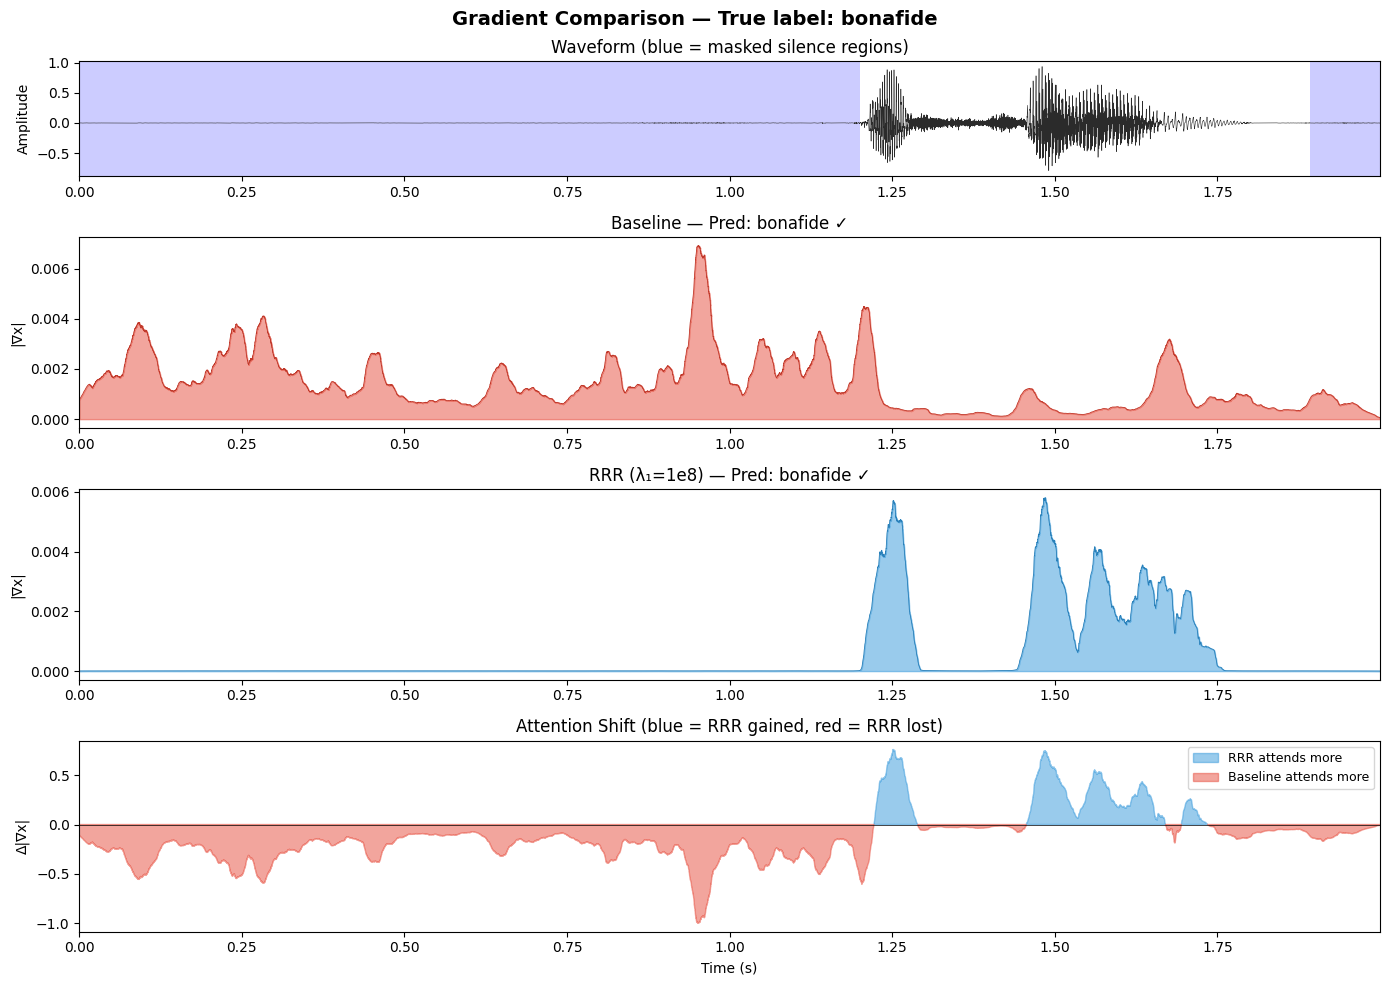

In [40]:
fig = visualize_comparison(
    baseline_model, rrr_model,
    torch.tensor(dev_demos[0][0]), int(dev_demos[0][1]),
    mask=dev_demos[0][3], device=DEVICE
)
fig.savefig('gradient_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [49]:
BATCH_SIZE = 128

train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn_asvspoof,
    pin_memory=True
)

dev_loader = DataLoader(
    dev_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn_asvspoof,
    pin_memory=True
)

eval_loader = DataLoader(
    eval_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn_asvspoof,
    pin_memory=True
)

Saved to gradient_batch_baseline_dev.png


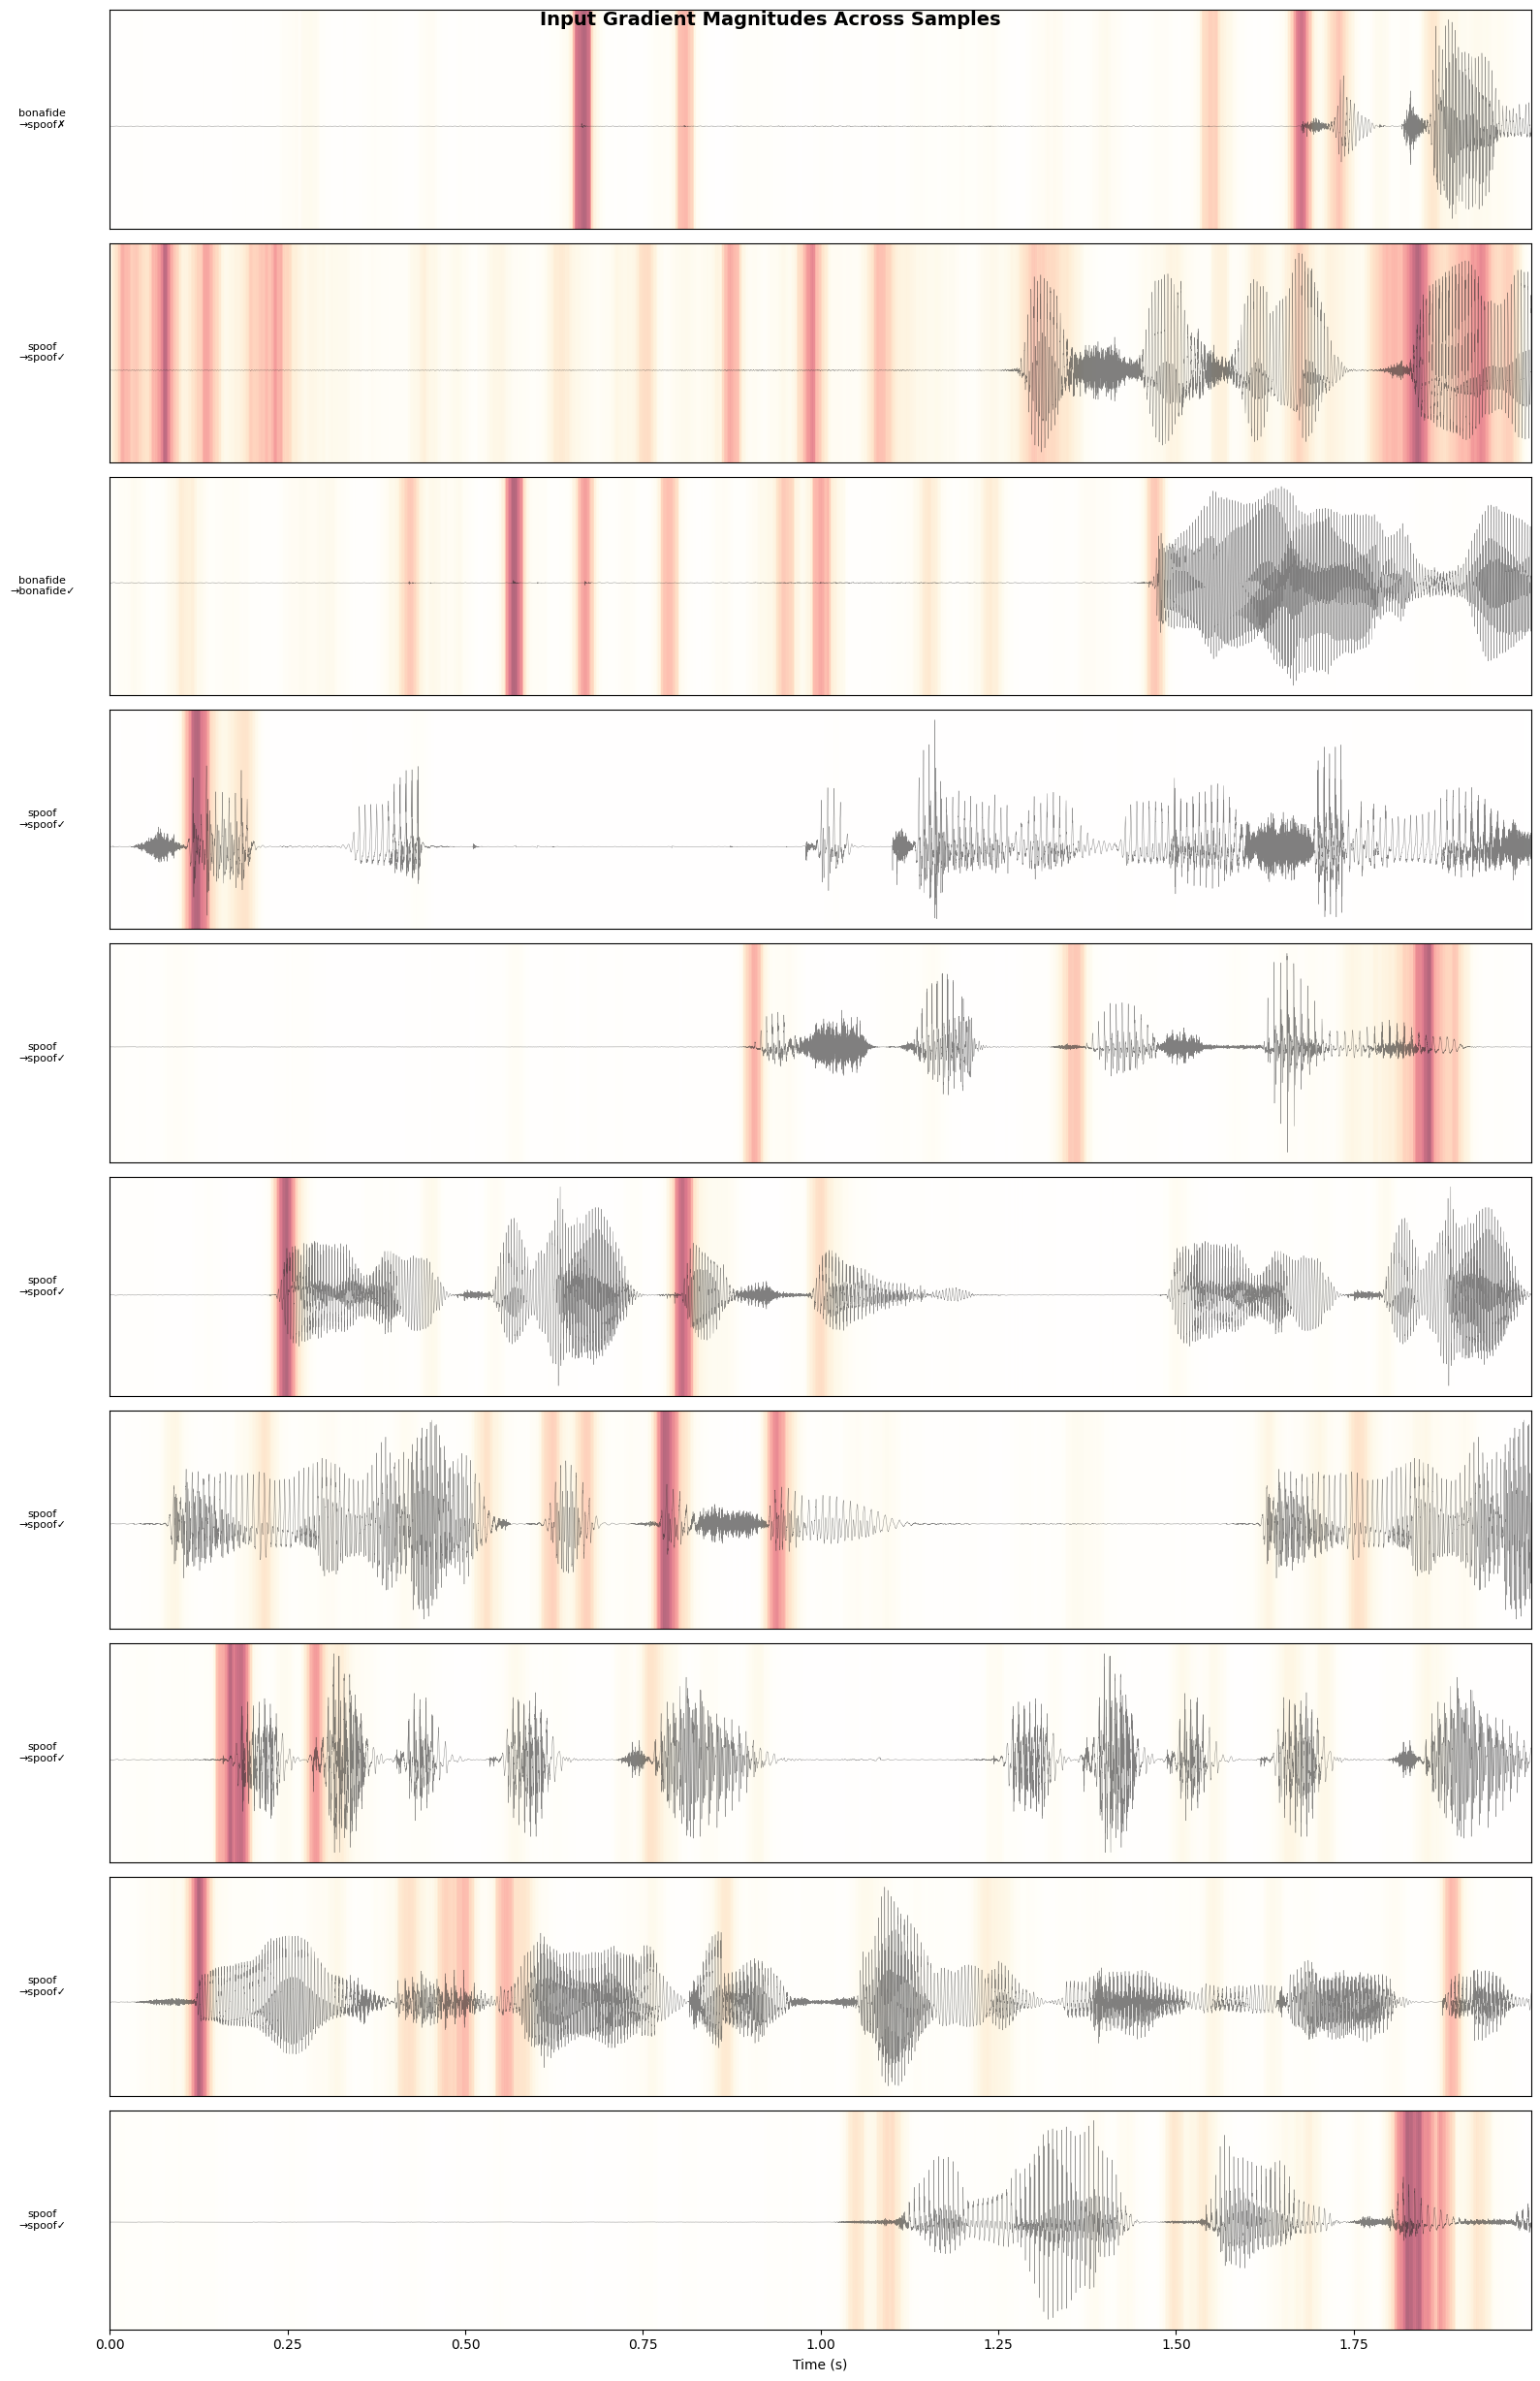

In [52]:
fig = visualize_batch(baseline_model, dev_loader, DEVICE, n_samples=10,
                      save_path='gradient_batch_baseline_dev.png')
plt.show()

Saved to gradient_batch_rrr_dev.png


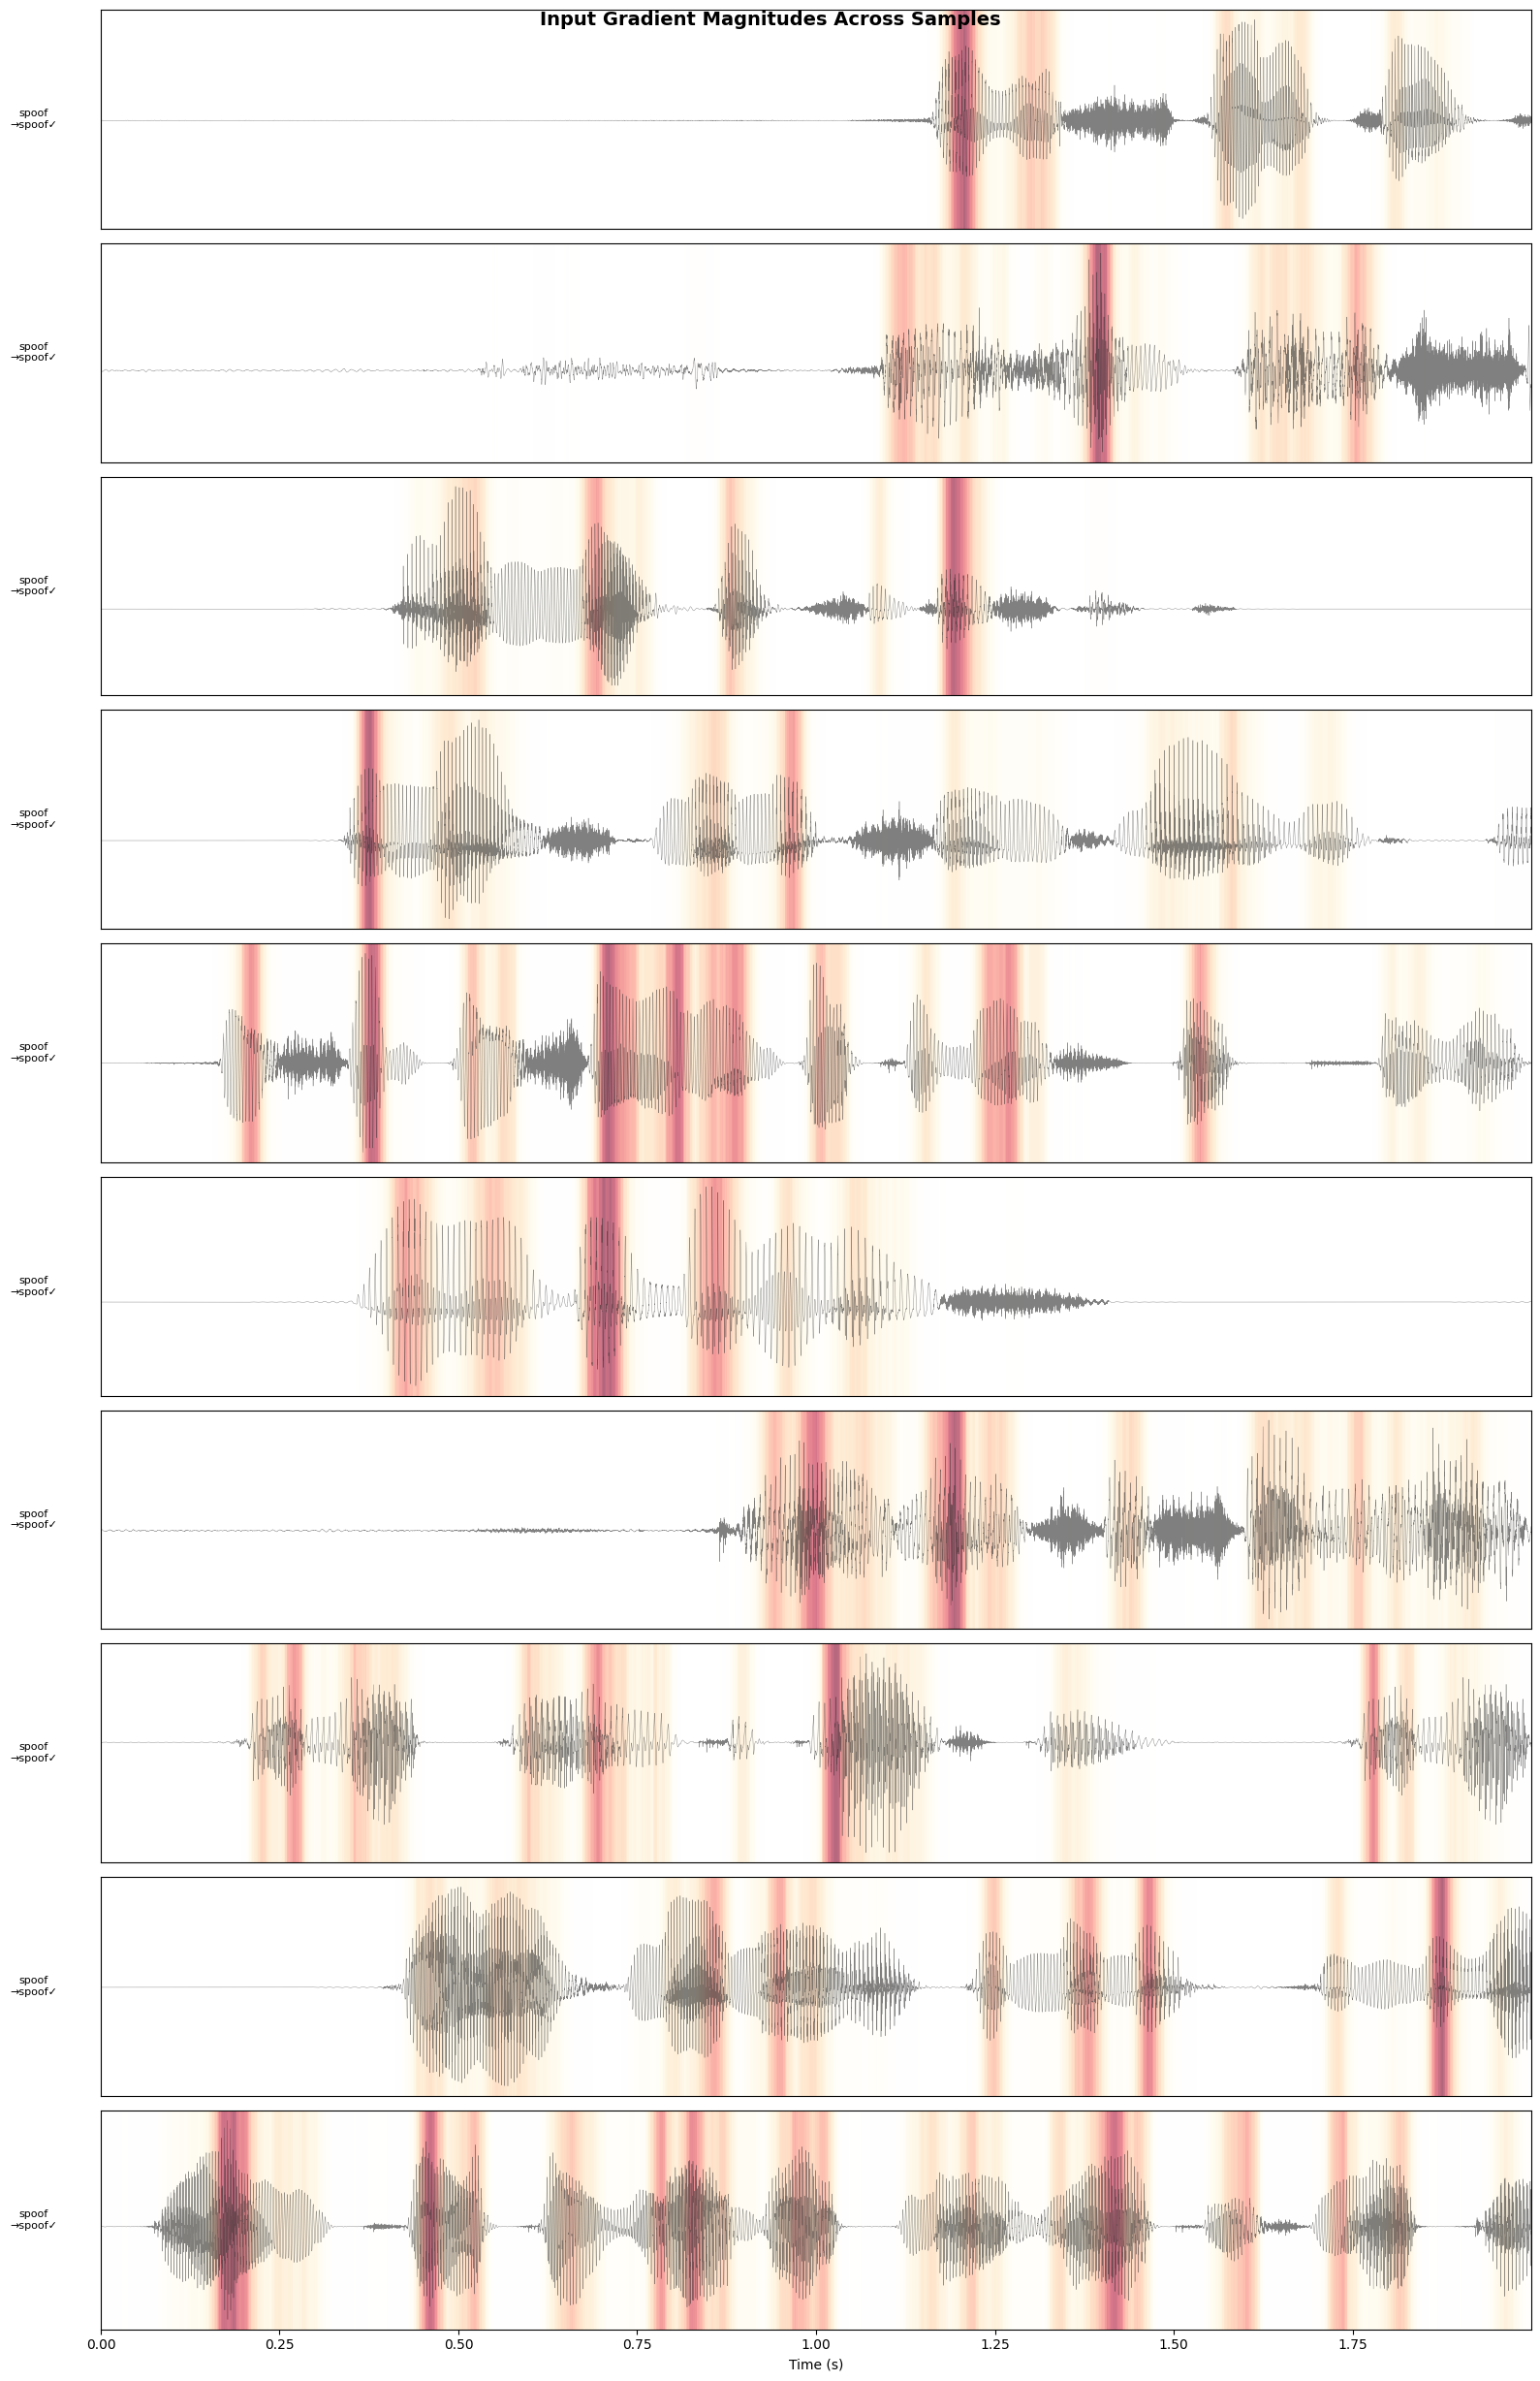

In [53]:
fig = visualize_batch(rrr_model, dev_loader, DEVICE, n_samples=10,
                      save_path='gradient_batch_rrr_dev.png')
plt.show()

Processed 10/195 batches...
Processed 20/195 batches...
Processed 30/195 batches...
Processed 40/195 batches...
Processed 50/195 batches...
Processed 60/195 batches...
Processed 70/195 batches...
Processed 80/195 batches...
Processed 90/195 batches...
Processed 100/195 batches...
Processed 110/195 batches...
Processed 120/195 batches...
Processed 130/195 batches...
Processed 140/195 batches...
Processed 150/195 batches...
Processed 160/195 batches...
Processed 170/195 batches...
Processed 180/195 batches...
Processed 190/195 batches...


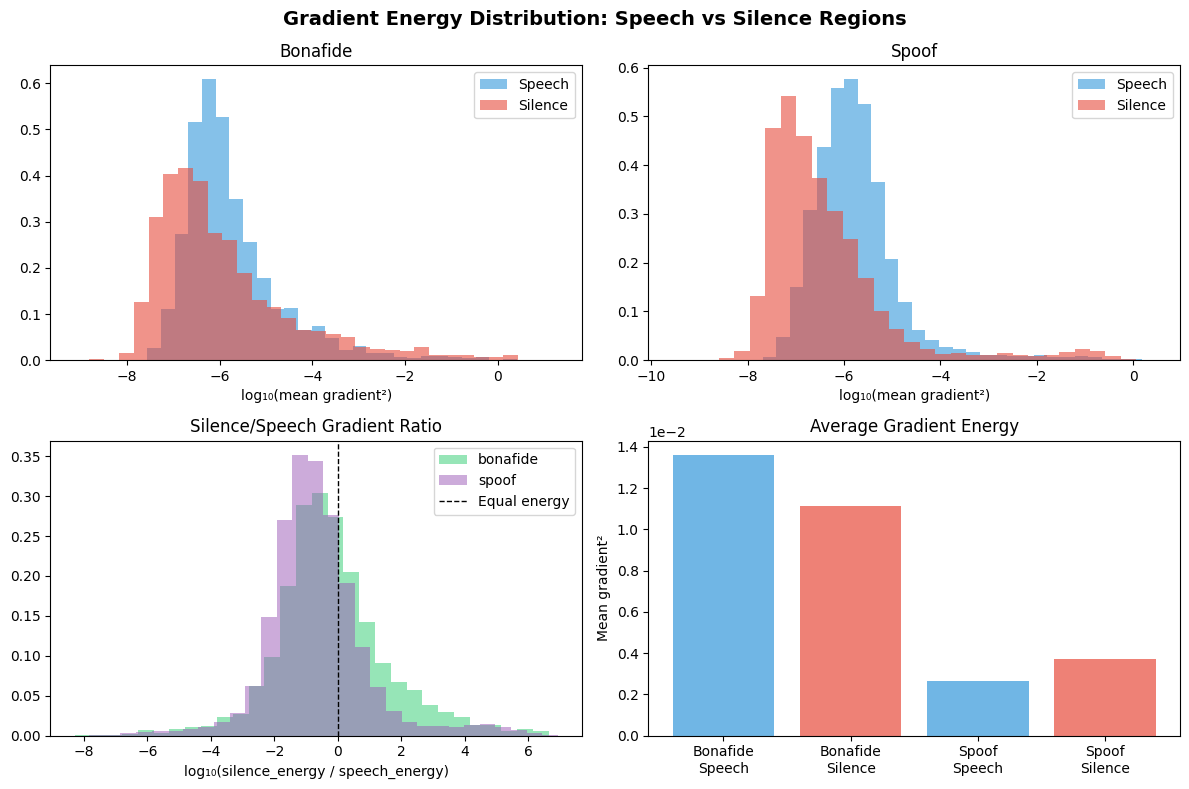

In [55]:
fig = visualize_gradient_stats(baseline_model, train_loader, DEVICE, max_batches=195)
fig.savefig('gradient_train_baseline_stats.png', dpi=150, bbox_inches='tight')
plt.show()

Processed 10/195 batches...
Processed 20/195 batches...
Processed 30/195 batches...
Processed 40/195 batches...
Processed 50/195 batches...
Processed 60/195 batches...
Processed 70/195 batches...
Processed 80/195 batches...
Processed 90/195 batches...
Processed 100/195 batches...
Processed 110/195 batches...
Processed 120/195 batches...
Processed 130/195 batches...
Processed 140/195 batches...
Processed 150/195 batches...
Processed 160/195 batches...
Processed 170/195 batches...
Processed 180/195 batches...
Processed 190/195 batches...


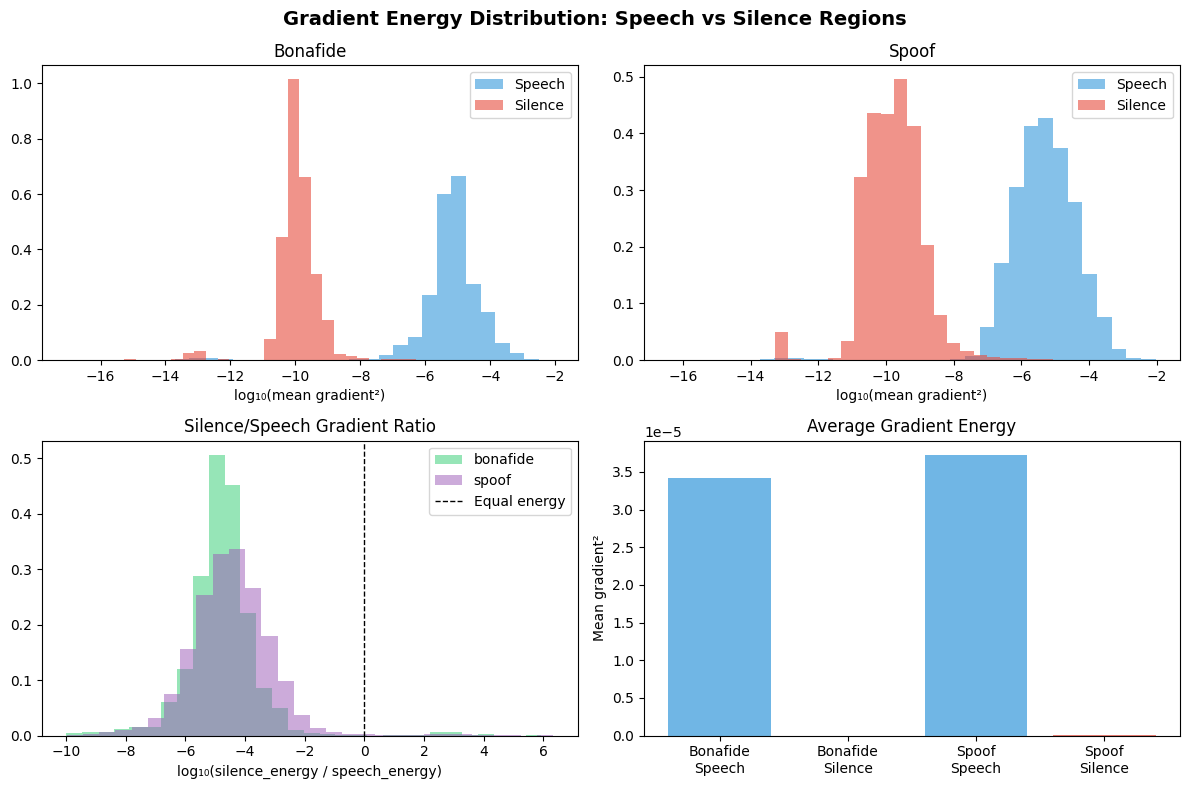

In [56]:
fig = visualize_gradient_stats(rrr_model, train_loader, DEVICE, max_batches=195)
fig.savefig('gradient_train_rrr_stats.png', dpi=150, bbox_inches='tight')
plt.show()

Processed 10/195 batches...
Processed 20/195 batches...
Processed 30/195 batches...
Processed 40/195 batches...
Processed 50/195 batches...
Processed 60/195 batches...
Processed 70/195 batches...
Processed 80/195 batches...
Processed 90/195 batches...
Processed 100/195 batches...
Processed 110/195 batches...
Processed 120/195 batches...
Processed 130/195 batches...
Processed 140/195 batches...
Processed 150/195 batches...
Processed 160/195 batches...
Processed 170/195 batches...
Processed 180/195 batches...
Processed 190/195 batches...


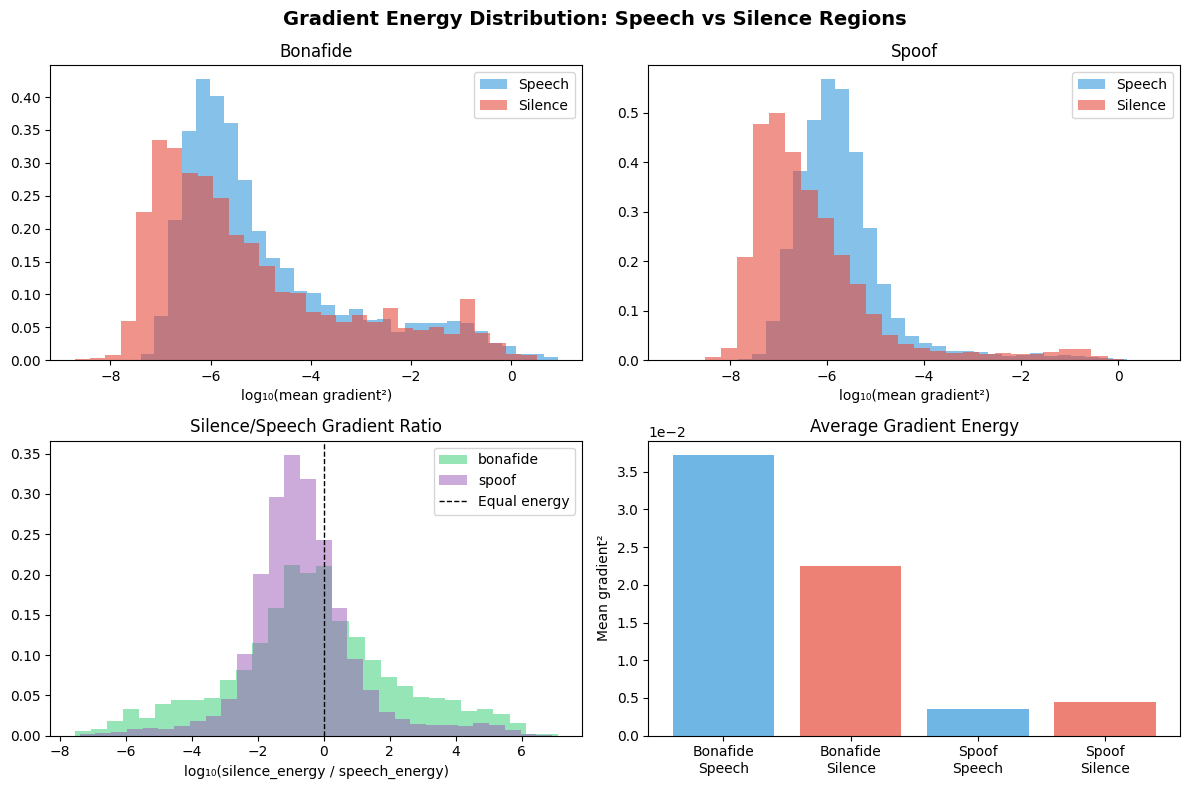

In [57]:
fig = visualize_gradient_stats(baseline_model, dev_loader, DEVICE, max_batches=195)
fig.savefig('gradient_dev_baseline_stats.png', dpi=150, bbox_inches='tight')
plt.show()

Processed 10/195 batches...
Processed 20/195 batches...
Processed 30/195 batches...
Processed 40/195 batches...
Processed 50/195 batches...
Processed 60/195 batches...
Processed 70/195 batches...
Processed 80/195 batches...
Processed 90/195 batches...
Processed 100/195 batches...
Processed 110/195 batches...
Processed 120/195 batches...
Processed 130/195 batches...
Processed 140/195 batches...
Processed 150/195 batches...
Processed 160/195 batches...
Processed 170/195 batches...
Processed 180/195 batches...
Processed 190/195 batches...


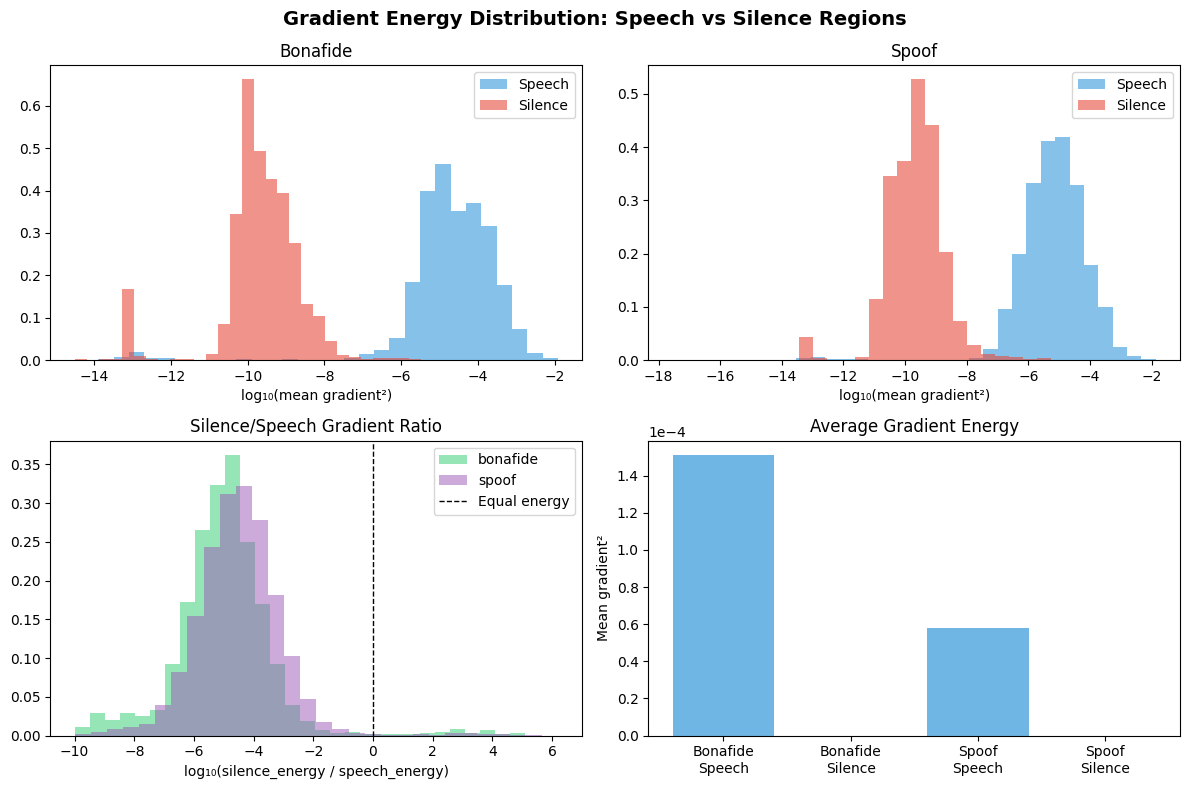

In [58]:
fig = visualize_gradient_stats(rrr_model, dev_loader, DEVICE, max_batches=195)
fig.savefig('gradient_dev_rrr_stats.png', dpi=150, bbox_inches='tight')
plt.show()

Processed 10/557 batches...
Processed 20/557 batches...
Processed 30/557 batches...
Processed 40/557 batches...
Processed 50/557 batches...
Processed 60/557 batches...
Processed 70/557 batches...
Processed 80/557 batches...
Processed 90/557 batches...
Processed 100/557 batches...
Processed 110/557 batches...
Processed 120/557 batches...
Processed 130/557 batches...
Processed 140/557 batches...
Processed 150/557 batches...
Processed 160/557 batches...
Processed 170/557 batches...
Processed 180/557 batches...
Processed 190/557 batches...
Processed 200/557 batches...
Processed 210/557 batches...
Processed 220/557 batches...
Processed 230/557 batches...
Processed 240/557 batches...
Processed 250/557 batches...
Processed 260/557 batches...
Processed 270/557 batches...
Processed 280/557 batches...
Processed 290/557 batches...
Processed 300/557 batches...
Processed 310/557 batches...
Processed 320/557 batches...
Processed 330/557 batches...
Processed 340/557 batches...
Processed 350/557 batch

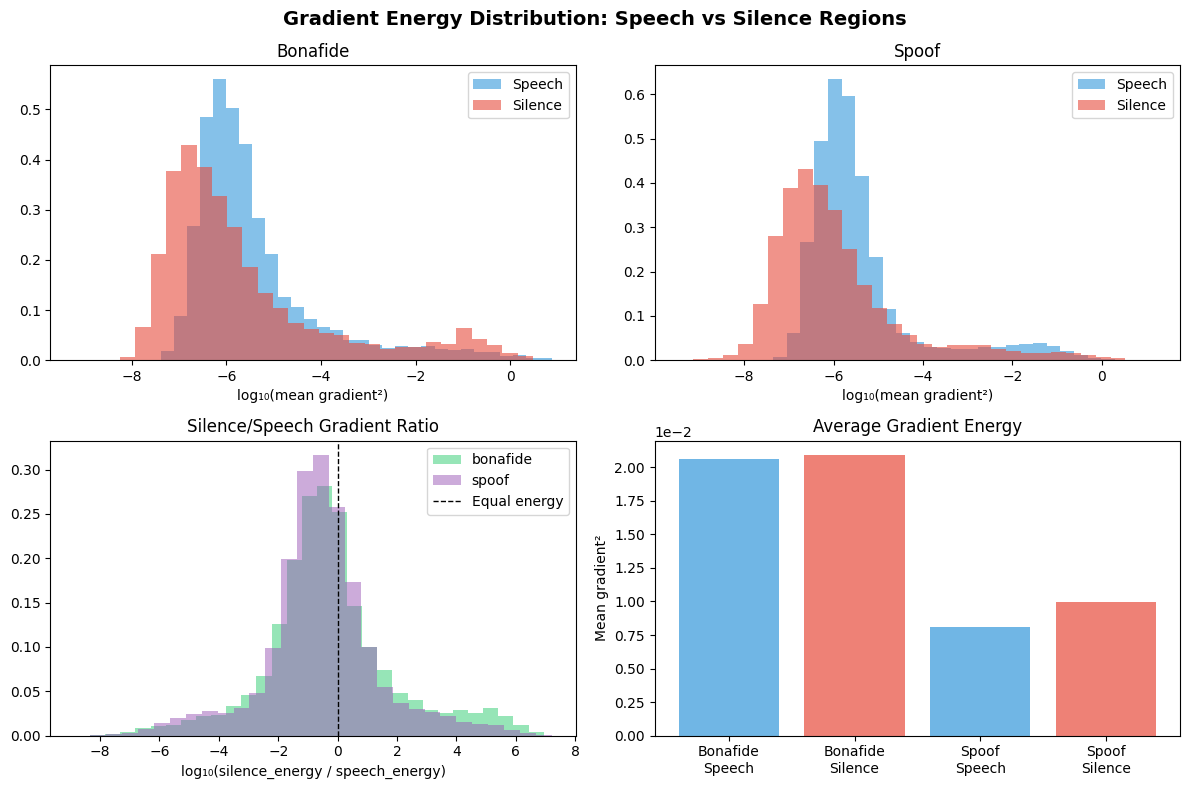

In [59]:
fig = visualize_gradient_stats(baseline_model, eval_loader, DEVICE, max_batches=557)
fig.savefig('gradient_eval_baseline_stats.png', dpi=150, bbox_inches='tight')
plt.show()

Processed 10/557 batches...
Processed 20/557 batches...
Processed 30/557 batches...
Processed 40/557 batches...
Processed 50/557 batches...
Processed 60/557 batches...
Processed 70/557 batches...
Processed 80/557 batches...
Processed 90/557 batches...
Processed 100/557 batches...
Processed 110/557 batches...
Processed 120/557 batches...
Processed 130/557 batches...
Processed 140/557 batches...
Processed 150/557 batches...
Processed 160/557 batches...
Processed 170/557 batches...
Processed 180/557 batches...
Processed 190/557 batches...
Processed 200/557 batches...
Processed 210/557 batches...
Processed 220/557 batches...
Processed 230/557 batches...
Processed 240/557 batches...
Processed 250/557 batches...
Processed 260/557 batches...
Processed 270/557 batches...
Processed 280/557 batches...
Processed 290/557 batches...
Processed 300/557 batches...
Processed 310/557 batches...
Processed 320/557 batches...
Processed 330/557 batches...
Processed 340/557 batches...
Processed 350/557 batch

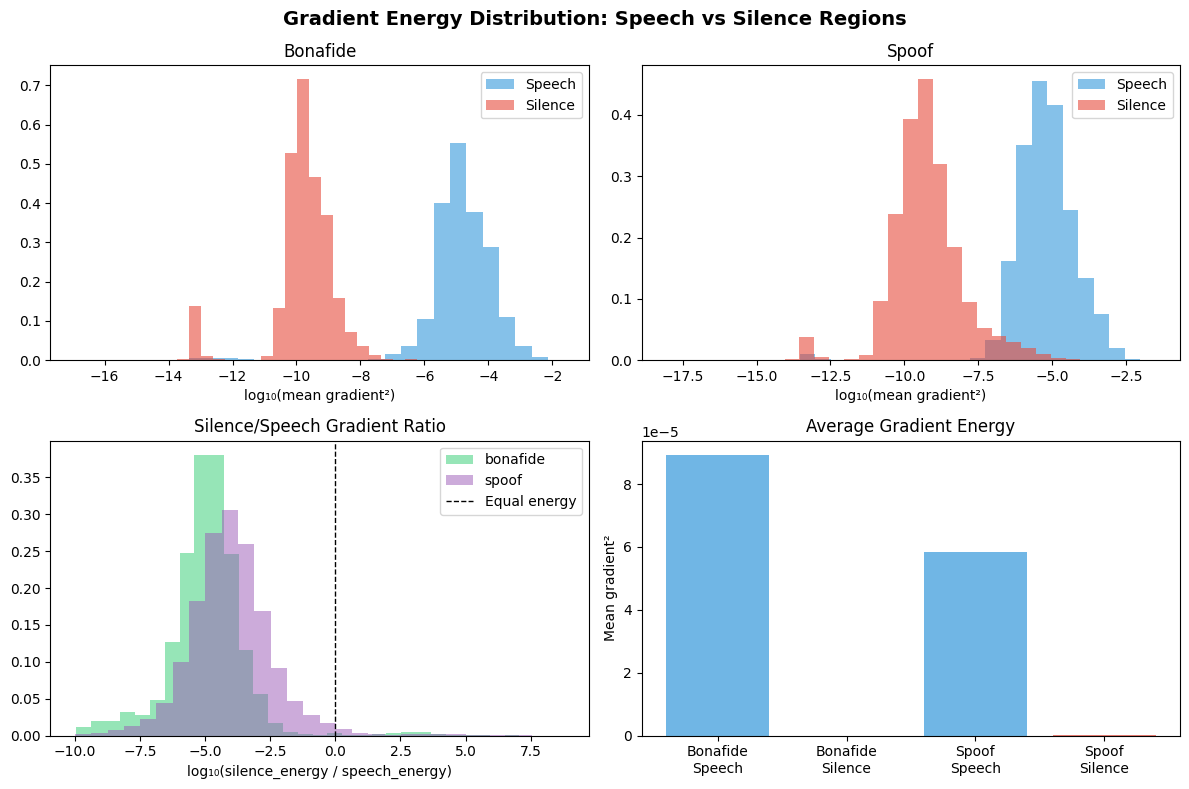

In [60]:
fig = visualize_gradient_stats(rrr_model, eval_loader, DEVICE, max_batches=557)
fig.savefig('gradient_eval_rrr_stats.png', dpi=150, bbox_inches='tight')
plt.show()